In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [3]:
# importing our data
churn_clean = pd.read_csv("churn_clean.csv")

# Code adapted from Dr. Kesselly Kamara's Panopto videos on PCA

# selecting only our variables that are numbers
PCA_data = churn_clean.select_dtypes("number")
print(PCA_data.columns)

Index(['CaseOrder', 'Zip', 'Lat', 'Lng', 'Population', 'Children', 'Age',
       'Income', 'Outage_sec_perweek', 'Email', 'Contacts',
       'Yearly_equip_failure', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year',
       'Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8'],
      dtype='object')


In [4]:
# dropping numeric values that are discrete
PCA_data = PCA_data.drop(["CaseOrder", "Zip", "Children", "Age", "Email", "Contacts", "Item1", "Item2", "Item3", "Item4", "Item5", "Item6", "Item7", "Item8"], axis=1)
print(PCA_data.columns)

Index(['Lat', 'Lng', 'Population', 'Income', 'Outage_sec_perweek',
       'Yearly_equip_failure', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year'],
      dtype='object')


In [5]:
# scaling the data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(PCA_data)

# putting the scaled data in a data frame and exporting it
scaled_PCA_data = pd.DataFrame(scaled_df, columns = PCA_data.columns)
scaled_PCA_data.to_csv("scaled_PCA_data.csv")

In [15]:
# initializing PCA and creating the matrix
pca = PCA()

PC = pca.fit_transform(scaled_PCA_data)

matrix = pd.DataFrame(pca.components_, columns = scaled_PCA_data.columns, index = ("PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9"))

matrix

,Lat,Lng,Population,Income,Outage_sec_perweek,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year
PC1,-0.023889,0.007874,-0.000656,0.003849,0.005825,0.017257,0.705515,0.040630,0.706837
PC2,-0.723017,0.178209,0.665299,-0.048784,0.005890,0.003086,-0.012445,-0.011297,-0.012590
PC3,0.104132,-0.788290,0.328134,0.113093,-0.260786,0.126124,0.029713,-0.403079,0.004572
PC4,-0.099719,0.426826,-0.196163,0.402068,-0.605128,0.157900,0.023379,-0.464803,-0.005982
PC5,-0.022596,0.012267,-0.014513,0.276807,0.381660,0.878884,-0.017632,0.062649,-0.013026
PC6,-0.006720,-0.124877,0.095328,0.825163,0.002211,-0.290772,-0.026720,0.457269,0.004225
PC7,-0.003670,-0.092255,0.016316,-0.256134,-0.647270,0.317126,-0.038652,0.636066,0.001922
PC8,0.674772,0.374621,0.633767,0.005926,-0.033383,0.036048,0.010592,-0.006967,0.008411
PC9,0.001097,0.000777,0.000300,-0.001252,0.000023,-0.000038,-0.705715,-0.045371,0.707040


In [14]:
print(pca.explained_variance_ratio_)

[0.22156409 0.13640921 0.11582745 0.11335043 0.11135683 0.11063826
 0.10836988 0.08176659 0.00071725]


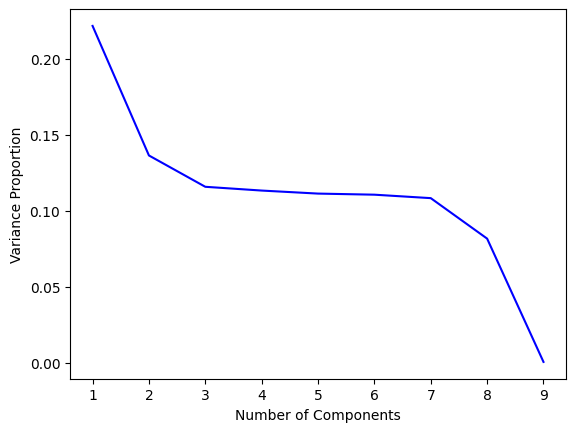

In [9]:
# putting together the elbow method scree plot

exp_variance = pca.explained_variance_ratio_

num_components = np.arange(pca.n_components_) + 1 # so the array starts at 1 to work w/ graph

plt.plot(num_components, exp_variance, "b-")
plt.xlabel("Number of Components")
plt.ylabel("Variance Proportion")
plt.show()

In [16]:
print("Variance of first 3 PCs: ")
print(pca.explained_variance_[:3])

total_variance = np.sum(num_components[:3]) / np.sum(num_components)
print("Total variance: ")
print(total_variance)

Variance of first 3 PCs: 
[1.99427624 1.22780571 1.04255133]
Total variance: 
0.13333333333333333


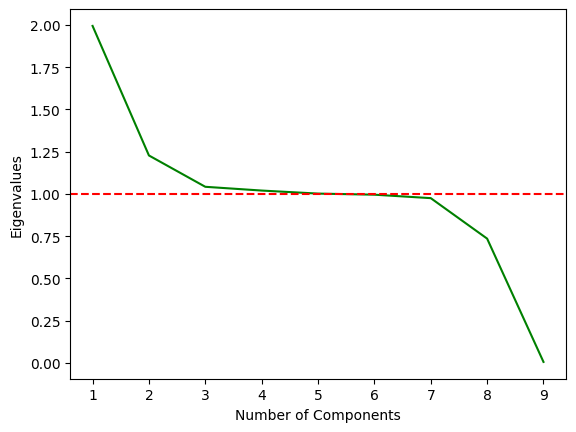

In [17]:
# checking kaiser criterion too

variance = pca.explained_variance_

plt.plot(num_components, variance, "g")
plt.xlabel("Number of Components")
plt.ylabel("Eigenvalues")
plt.axhline(y=1, color = "r", linestyle = "dashed")
plt.show()

In [12]:
print("Variance of first 5 PCs: ")
print(pca.explained_variance_[:5])

print()
print("Total explained variance: ")
print(np.sum(pca.explained_variance_ratio_[:5]))

Variance of first 5 PCs: 
[1.99427624 1.22780571 1.04255133 1.02025591 1.00231173]

Total explained variance: 
0.6985080233026421
